In [1]:
from lsst.daf.butler import Butler

REPO = "/repo/main"                      # LSSTCam/runs/... collections live in /repo/main
DATASET_TYPE = "aggregateAOSVisitTableRaw"
COLLECTIONS = [
    "LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs",
    "LSSTCam/runs/aos/cwfs/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/2025",
]

butler = Butler(REPO)

for coll in COLLECTIONS:
    print(f"\n=== {coll} ===")

    # queryDimensionRecords(datasets=..., collections=...) returns the visit/exposure
    # records for which the dataset actually exists — exactly "where is the table present".
    recs = []
    for dim in ("visit", "exposure"):
        try:
            recs = list(butler.registry.queryDimensionRecords(
                dim, datasets=DATASET_TYPE, collections=coll))
        except Exception:
            recs = []
        if recs:
            print(f"  dataset dimensioned by '{dim}': {len(recs)} present")
            break

    if not recs:
        print(f"  no '{DATASET_TYPE}' found. Candidate dataset types registered:")
        for dt in sorted(butler.registry.queryDatasetTypes()):
            if "aggregate" in dt.name.lower() or "aosvisit" in dt.name.lower():
                print("   ", dt.name)
        continue

    # Sort and print day_obs, seq_num
    for r in sorted(recs, key=lambda r: (r.day_obs, r.seq_num)):
        print(f"    day_obs={r.day_obs}  seq_num={r.seq_num:>6d}")

    # Compact per-day summary
    from collections import Counter
    by_day = Counter(r.day_obs for r in recs)
    print("  summary (day_obs: n_visits): "
          + ", ".join(f"{d}:{n}" for d, n in sorted(by_day.items())))


=== LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs ===
  dataset dimensioned by 'visit': 2333 present
    day_obs=20250415  seq_num=    75
    day_obs=20250415  seq_num=    78
    day_obs=20250415  seq_num=    81
    day_obs=20250415  seq_num=    84
    day_obs=20250415  seq_num=    87
    day_obs=20250415  seq_num=    90
    day_obs=20250417  seq_num=   566
    day_obs=20250417  seq_num=   569
    day_obs=20250417  seq_num=   572
    day_obs=20250417  seq_num=   634
    day_obs=20250417  seq_num=   637
    day_obs=20250417  seq_num=   640
    day_obs=20250417  seq_num=   643
    day_obs=20250417  seq_num=   646
    day_obs=20250417  seq_num=   649
    day_obs=20250417  seq_num=   666
    day_obs=20250417  seq_num=   669
    day_obs=20250417  seq_num=   672
    day_obs=20250417  seq_num=   675
    day_obs=20250417  seq_num=   678
    day_obs=20250417  seq_num=   681
    day_obs=20250417  seq_num=   684
    day_obs=20250417  seq_num=   687
    day_obs=2025

In [2]:
from lsst.daf.butler import Butler, MissingCollectionError

REPO = "/repo/main"
DATASET_TYPE = "aggregateAOSVisitTableRaw"
CANDIDATES = [
    "LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs",
    "LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/2025",
]

butler = Butler(REPO)

def day_obs_of(coll):
    """Sorted list of day_obs that have the aggregate present in `coll`."""
    for dim in ("visit", "exposure"):
        try:
            recs = list(butler.registry.queryDimensionRecords(
                dim, datasets=DATASET_TYPE, collections=coll))
        except Exception:
            recs = []
        if recs:
            return sorted({r.day_obs for r in recs}), len(recs)
    return [], 0

for coll in CANDIDATES:
    print(f"\n=== {coll} ===")
    try:
        ctype = butler.registry.getCollectionType(coll)
    except MissingCollectionError:
        print("  DOES NOT EXIST")
        continue
    print(f"  exists — type: {ctype.name}")

    # If it's a CHAINED collection, show its children
    if ctype.name == "CHAINED":
        children = list(butler.registry.getCollectionChain(coll))
        print(f"  chain ({len(children)}):")
        for c in children:
            print("    -", c)

    days, n = day_obs_of(coll)
    if n == 0:
        print("  no aggregate datasets present")
    else:
        y2025 = [d for d in days if 20250000 <= d < 20260000]
        print(f"  {n} datasets over {len(days)} nights: {days[0]}..{days[-1]}")
        print(f"  2025 nights present: {len(y2025)}"
              + (f"  ({y2025[0]}..{y2025[-1]})" if y2025 else ""))


=== LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs ===
  exists — type: CHAINED
  chain (121):
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260521/20260716T181144Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260521/20260521_step2/20260717T174347Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260522/20260716T181211Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260522/20260522_step2/20260717T174417Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260619/20260716T181242Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260619/20260619_step2/20260717T174443Z
    - u/scichris/LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs/20260709/202607

In [3]:
days, n = day_obs_of("LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs")
print(n, "datasets;", days[0], "..", days[-1])
print("2025 nights:", [d for d in days if 20250000 <= d < 20260000])

2333 datasets; 20250415 .. 20260711
2025 nights: [20250415, 20250417, 20250418, 20250419, 20250420, 20250421, 20250422, 20250423, 20250424, 20250425, 20250426, 20250427, 20250505, 20250507, 20250511, 20250512, 20250513, 20250519, 20250520, 20250521, 20250522, 20250523, 20250524, 20250525, 20250527, 20250529, 20250531, 20250601, 20250619, 20250706, 20250707, 20250808, 20250809, 20250810, 20250812, 20250813, 20250814, 20250816, 20250825, 20250826, 20250827, 20250828, 20250902, 20250903, 20250904, 20250907, 20250909, 20250911, 20250912, 20250913, 20250921, 20251022, 20251023, 20251024, 20251026, 20251027, 20251028, 20251031, 20251101, 20251102, 20251103, 20251104, 20251105, 20251107, 20251108, 20251109, 20251110, 20251111, 20251112, 20251113, 20251114, 20251115, 20251116, 20251117, 20251118, 20251119, 20251120, 20251121, 20251122, 20251123, 20251124, 20251125, 20251126, 20251127, 20251128, 20251129, 20251130, 20251201, 20251202, 20251203, 20251204, 20251206, 20251208, 20251209, 20251210, 

In [4]:
from collections import Counter

COLL = "LSSTCam/runs/aos/fam/danish_1_2_0/wep_17_7_0/dv_4_7_0/bin_x2/paired/refitWcs"
DATASET_TYPE = "aggregateAOSVisitTableRaw"
CONFIGURED = {"T278", "T381", "T492", "T539", "T614", "T710", "T717", "T720", "T724"}

def program_of(rec):
    for attr in ("science_program", "program"):   # field name varies by Butler version
        if hasattr(rec, attr):
            return getattr(rec, attr)
    return None

# records (visit or exposure) that actually have the aggregate present
recs, used_dim = [], None
for dim in ("visit", "exposure"):
    try:
        recs = list(butler.registry.queryDimensionRecords(
            dim, datasets=DATASET_TYPE, collections=COLL))
    except Exception:
        recs = []
    if recs:
        used_dim = dim
        break

# restrict to 2025 and tally the programs
recs_2025 = [r for r in recs if 20250000 <= r.day_obs < 20260000]
prog = Counter(program_of(r) for r in recs_2025)

print(f"dim={used_dim}   2025 visits with {DATASET_TYPE}: {len(recs_2025)}")
print("programs present (raw value : n_visits):")
for p, n in sorted(prog.items(), key=lambda kv: (-kv[1], str(kv[0]))):
    flag = "" if str(p) in CONFIGURED else "   <-- NOT in fam_programs"
    print(f"  {str(p):16s} {n:5d}{flag}")

present = {str(p) for p in prog}
print("\nprograms present but NOT configured:", sorted(present - CONFIGURED))
print("configured but NOT present in 2025 :", sorted(CONFIGURED - present))

dim=visit   2025 visits with aggregateAOSVisitTableRaw: 2243
programs present (raw value : n_visits):
  BLOCK-T614_triplets   318   <-- NOT in fam_programs
  BLOCK-T606         264   <-- NOT in fam_programs
  BLOCK-T559_v3      223   <-- NOT in fam_programs
  BLOCK-T539         145   <-- NOT in fam_programs
  BLOCK-T381         127   <-- NOT in fam_programs
  BLOCK-T278         103   <-- NOT in fam_programs
  BLOCK-T630          96   <-- NOT in fam_programs
  BLOCK-T278_v2       90   <-- NOT in fam_programs
  BLOCK-T380          83   <-- NOT in fam_programs
  BLOCK-T598          81   <-- NOT in fam_programs
  BLOCK-T503          77   <-- NOT in fam_programs
  BLOCK-T492          72   <-- NOT in fam_programs
  BLOCK-T197          71   <-- NOT in fam_programs
  BLOCK-T378_1        46   <-- NOT in fam_programs
  BLOCK-T393_v4       39   <-- NOT in fam_programs
  BLOCK-T417          37   <-- NOT in fam_programs
  BLOCK-T395          34   <-- NOT in fam_programs
  BLOCK-T378_3        32   <

In [5]:
from collections import Counter

SMATRIX = ["T197", "T377", "T378", "T379", "T380", "T503", "T606"]         # optical state changed
STABLE  = ["T614", "T381", "T393", "T395", "T475", "T492", "T539",         # stable conditions
           "T278", "T717", "T720", "T724"]                                  # (+ original set)

def hits(value, tokens):
    v = str(value)
    return [t for t in tokens if t in v]        # substring, like run_mktable's str.contains

n_smatrix = n_stable = n_both = n_other = 0
other = Counter()
both = []
for p, n in prog.items():                        # prog: Counter{raw_program: n_visits} from prior step
    hs, ht = hits(p, SMATRIX), hits(p, STABLE)
    if hs and ht:
        n_both += n; both.append((p, hs, ht))
    elif hs:
        n_smatrix += n
    elif ht:
        n_stable += n
    else:
        n_other += n; other[p] += n

tot = sum(prog.values())
print(f"total 2025 FAM visits: {tot}")
print(f"  S-matrix blocks : {n_smatrix:5d}  ({100*n_smatrix/tot:.1f}%)")
print(f"  stable  blocks  : {n_stable:5d}  ({100*n_stable/tot:.1f}%)")
print(f"  in BOTH sets    : {n_both:5d}   <- should be 0; substring overlap if not")
print(f"  in NEITHER set  : {n_other:5d}  ({100*n_other/tot:.1f}%)")

print("\nunclassified programs (in neither set):")
for p, n in other.most_common():
    print(f"  {p:22s} {n}")
if both:
    print("\nambiguous (matched both sets):")
    for p, hs, ht in both:
        print(f"  {p:22s}  S={hs}  stable={ht}")

total 2025 FAM visits: 2243
  S-matrix blocks :   756  (33.7%)
  stable  blocks  :   981  (43.7%)
  in BOTH sets    :     0   <- should be 0; substring overlap if not
  in NEITHER set  :   506  (22.6%)

unclassified programs (in neither set):
  BLOCK-T559_v3          223
  BLOCK-T630             96
  BLOCK-T598             81
  BLOCK-T417             37
  BLOCK-T609_1           20
  BLOCK-T459             15
  CWFS                   13
  AOSSEQUENCE            11
  BLOCK-T615             5
  BLOCK-T626             2
  BLOCK-T460             2
  BLOCK-T519             1


In [2]:
import pandas as pd, os
PS = "fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x"
chunks = ["20250415_20250531", "20250601_20250930", "20251001_20251115",
          "20251116_20251130", "20251201_20251231"]
key = "z_gradient"

def status(path):
    if not os.path.exists(path):
        return "MISSING", 0, 0
    t = pd.read_parquet(path)
    if key not in t.columns:
        return "NO-THERMAL (col absent)", 0, len(t)
    nz = int(t[key].notna().sum())
    v = "OK" if nz == len(t) else ("NEEDS BACKFILL" if nz == 0 else f"PARTIAL {nz}/{len(t)}")
    return v, nz, len(t)

print(f"{'chunk':22s} {'visits.parquet':>28s}   {'fits.parquet':>28s}")
for w in chunks:
    vv, nzv, nv = status(f"output/{PS}/chunks/{w}/visits.parquet")
    ff, nzf, nf = status(f"output/{PS}/chunks/{w}/fits.parquet")
    print(f"{w:22s} {vv:>20s} {nv:4d}v   {ff:>20s} {nf:4d}v")

# combined param-set tables (rebuilt only after backfill + re-combine)
for name in ("visits", "fits"):
    s, nz, n = status(f"output/{PS}/{name}.parquet")
    print(f"combined {name}.parquet: {s}  ({nz}/{n})")

chunk                                visits.parquet                   fits.parquet
20250415_20250531           PARTIAL 258/637  637v        PARTIAL 171/443  443v
20250601_20250930                        OK  811v                     OK  459v
20251001_20251115                        OK  361v                     OK  301v
20251116_20251130                        OK   53v                     OK   47v
20251201_20251231                        OK  319v                     OK  252v
combined visits.parquet: OK  (1204/1204)
combined fits.parquet: OK  (1026/1026)


In [6]:
from astropy.time import Time
from lsst.summit.utils.efdUtils import makeEfdClient
from lsst.ts.m1m3.utils import ThermocoupleAnalysis

async def main():
    efd = makeEfdClient()
    for label, d0, d1 in [("early ~20250420", "2025-04-20T12:00:00", "2025-04-21T12:00:00"),
                          ("later ~20250520", "2025-05-20T12:00:00", "2025-05-21T12:00:00")]:
        ta = ThermocoupleAnalysis(efd)
        try:
            await ta.load(Time(d0, scale="utc"), Time(d1, scale="utc"), time_bin=30)
            g = ta.xyz_r_gradients
            print(f"{label}: xyz_r_gradients =",
                  "None (no M1M3 thermal in EFD)" if g is None else f"{len(g)} rows OK")
        except Exception as e:
            print(f"{label}: FAILED {type(e).__name__}: {e}")

await main()          # <-- notebook: top-level await, not asyncio.run(...)

early ~20250420: xyz_r_gradients = None (no M1M3 thermal in EFD)


/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.1.0-exact/lib/python3.13/site-packages/pandas/core/flags.py:51: RuntimeWarning: coroutine 'main' was never awaited
  def __init__(self, obj: NDFrame, *, allows_duplicate_labels: bool) -> None:


later ~20250520: xyz_r_gradients = 2217 rows OK


rows: 3385   nights: 106   day_obs: 20250415–20260713
2025: 2181  2026: 1204
  z_gradient     valid 3006/3385
  cam_air_temp   valid 3192/3385
  x_gradient     valid 3006/3385
  y_gradient     valid 3006/3385
top programs: {'BLOCK-T614_triplets': np.int64(1262), 'BLOCK-T606': np.int64(264), 'BLOCK-T559_v3': np.int64(222), 'BLOCK-T381': np.int64(127), 'BLOCK-T539': np.int64(113), 'BLOCK-T720': np.int64(106), 'BLOCK-T278': np.int64(103), 'BLOCK-T278_v2': np.int64(90)}


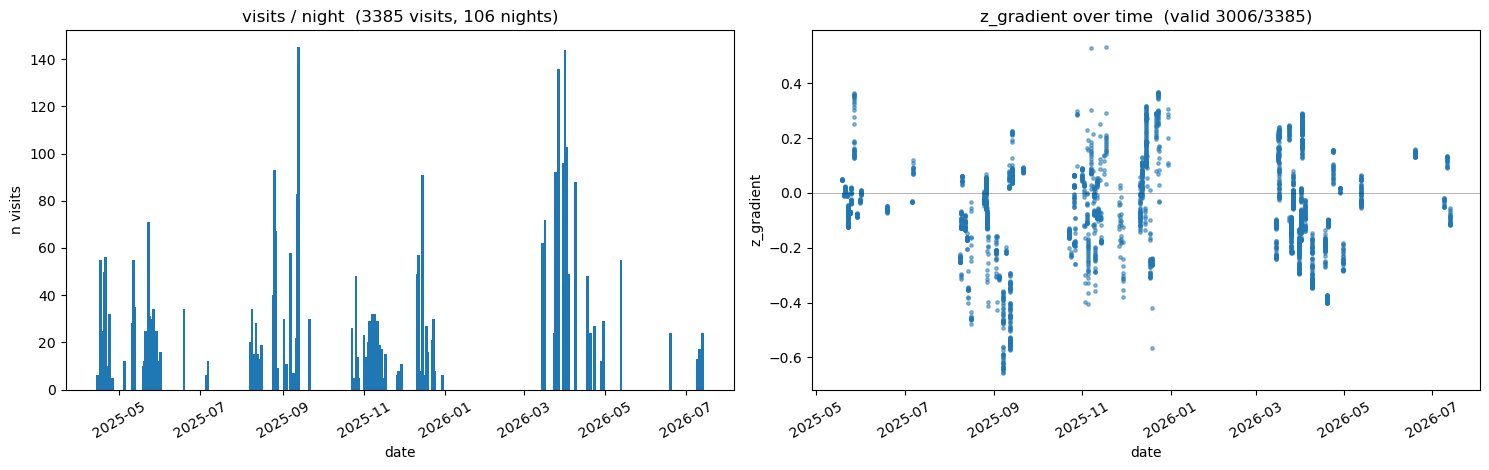

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

PS = "fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x"
v = pd.read_parquet(f"output/{PS}/visits.parquet")
date = pd.to_datetime(v["day_obs"].astype(int).astype(str), format="%Y%m%d")

print(f"rows: {len(v)}   nights: {v.day_obs.nunique()}   "
      f"day_obs: {v.day_obs.min()}–{v.day_obs.max()}")
print("2025:", int((v.day_obs < 20260000).sum()), " 2026:", int((v.day_obs >= 20260000).sum()))
for c in ("z_gradient", "cam_air_temp", "x_gradient", "y_gradient"):
    if c in v:
        print(f"  {c:14s} valid {v[c].notna().sum():4d}/{len(v)}")
if "science_program" in v:
    print("top programs:", dict(v.science_program.value_counts().head(8)))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

# 1. coverage: visits per night across the campaign
vc = v.groupby("day_obs").size()
vd = pd.to_datetime(vc.index.astype(int).astype(str), format="%Y%m%d")
ax[0].bar(vd, vc.values, width=2.0)
ax[0].set_title(f"visits / night  ({len(v)} visits, {len(vc)} nights)")
ax[0].set_xlabel("date"); ax[0].set_ylabel("n visits"); ax[0].tick_params(axis="x", rotation=30)

# 2. thermal: z_gradient over time (gaps = no M1M3 EFD, e.g. early 2025)
if "z_gradient" in v:
    m = v["z_gradient"].notna().values
    ax[1].scatter(date[m], v["z_gradient"].values[m], s=6, alpha=0.5)
    ax[1].set_title(f"z_gradient over time  (valid {int(m.sum())}/{len(v)})")
    ax[1].set_xlabel("date"); ax[1].set_ylabel("z_gradient"); ax[1].tick_params(axis="x", rotation=30)
    ax[1].axhline(0, color="k", lw=0.5, alpha=0.4)

fig.tight_layout()
fig.savefig(f"output/{PS}/visits_check.pdf")
plt.show()

In [9]:
import sys; sys.path.insert(0, "code")
import pandas as pd, numpy as np
from run_coadd_blocks_miw import assign_blocks

PS = "fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x"
v = pd.read_parquet(f"output/{PS}/visits.parquet")
print(f"raw visits: {len(v)}")
if "median_blur_arcsec" in v:
    b = v["median_blur_arcsec"].to_numpy(float)
    for lo, hi in [(0, 1.2), (1.2, 1.4), (1.4, 1.5), (1.5, 99)]:
        print(f"  blur [{lo},{hi}): {int(np.sum((b >= lo) & (b < hi)))}")
if "band" in v:
    print("raw band counts:", dict(v["band"].value_counts()))

from run_coadd_blocks_miw import assign_blocks, block_summary   # add block_summary

def report(bands, max_blur, label):
    vb = assign_blocks(v, bands, set(), 5.0, 36.0, 10.0,
                       wide_programs=set(), wide_tol=20.0, max_blur=max_blur)
    bs = block_summary(vb, rot_windows=[])          # per-block summary (has n_visits)
    pl = bs[bs["n_visits"] >= 6]
    yr = np.where(pl["day_obs"].to_numpy() < 20260000, "2025", "2026")
    print(f"\n{label}: {len(bs)} blocks, {len(pl)} coadded (>=6 visits), "
          f"{int(pl['n_visits'].sum())} visits")
    print("  by band:", {k: int(x) for k, x in pl.groupby('band')['n_visits'].sum().items()})
    print("  by year:", {y: int(pl['n_visits'][yr == y].sum()) for y in ('2025', '2026')})

report(["i"], 1.4, "OLD  (i-band, blur<=1.4)")
report(["u", "g", "r", "i", "z", "y"], 1.5, "NEW  (all bands, blur<=1.5)")

raw visits: 3385
  blur [0,1.2): 2690
  blur [1.2,1.4): 446
  blur [1.4,1.5): 96
  blur [1.5,99): 153
raw band counts: {'i': np.int64(1792), 'r': np.int64(1270), 'z': np.int64(114), 'g': np.int64(101), 'u': np.int64(77), 'y': np.int64(31)}


/home/r/roodman/notebooks/rubin-work/aos/code/run_coadd_blocks_miw.py:229: RuntimeWarning: Mean of empty slice
  **{tv: (float(np.nanmean(g[tv])) if tv in g.columns else np.nan)



OLD  (i-band, blur<=1.4): 405 blocks, 118 coadded (>=6 visits), 1320 visits
  by band: {'i': 1320}
  by year: {'2025': 415, '2026': 905}


/home/r/roodman/notebooks/rubin-work/aos/code/run_coadd_blocks_miw.py:229: RuntimeWarning: Mean of empty slice
  **{tv: (float(np.nanmean(g[tv])) if tv in g.columns else np.nan)



NEW  (all bands, blur<=1.5): 893 blocks, 205 coadded (>=6 visits), 2242 visits
  by band: {'g': 73, 'i': 1358, 'r': 722, 'u': 36, 'y': 20, 'z': 33}
  by year: {'2025': 1279, '2026': 963}


In [6]:
import numpy as np
PS = "fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x"
d = np.load(f"output/{PS}/coadd_50_34/block_grids.npz")
ORD = 110                                   # this block's ordinal (from the title)
g, m = d["grids"][ORD], d["miw"][ORD]       # (4 Z, ny, nx)
def pear(a, b):
    ok = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[ok], b[ok])[0, 1] if ok.sum() > 5 else np.nan
def coarsen(A, f):
    ny, nx = (A.shape[0]//f)*f, (A.shape[1]//f)*f
    return np.nanmean(A[:ny, :nx].reshape(ny//f, f, nx//f, f), axis=(1, 3))
for f in (1, 2, 3, 4):
    rs = [pear(coarsen(g[i], f), coarsen(m[i], f)) for i in range(4)]
    rms = [np.sqrt(np.nanmean((coarsen(g[i], f)-coarsen(m[i], f))**2)) for i in range(4)]
    print(f"rebin {f}x{f}:  r={np.round(rs,2)} (mean {np.nanmean(rs):.2f})  "
          f"rms={np.round(rms,3)}")

rebin 1x1:  r=[0.53 0.59 0.44 0.59] (mean 0.54)  rms=[0.176 0.164 0.187 0.126]
rebin 2x2:  r=[0.63 0.68 0.6  0.69] (mean 0.65)  rms=[0.135 0.127 0.119 0.095]
rebin 3x3:  r=[0.74 0.76 0.68 0.78] (mean 0.74)  rms=[0.099 0.102 0.098 0.075]
rebin 4x4:  r=[0.76 0.76 0.77 0.79] (mean 0.77)  rms=[0.09  0.101 0.076 0.072]


/tmp/ipykernel_121/2409547902.py:11: RuntimeWarning: Mean of empty slice
  return np.nanmean(A[:ny, :nx].reshape(ny//f, f, nx//f, f), axis=(1, 3))
